# 🚛 Explainable AI for Predictive Maintenance
**Scania Component X Dataset**  
Kunal Singh Dadhwal 23BDS1097 | Tapan Batla 23BDS1151

## 1. Environment Setup
Mount Google Drive and extract the dataset into Colab's local storage for fast I/O.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!unzip "/content/drive/MyDrive/AI_DA_PREDICTIVE MAINTAINENCE/Dataset.zip" -d "/content/Dataset/"

Mounted at /content/drive
Archive:  /content/drive/MyDrive/AI_DA_PREDICTIVE MAINTAINENCE/Dataset.zip
   creating: /content/Dataset/Dataset/
  inflating: /content/Dataset/Dataset/train_operational_readouts.csv  
  inflating: /content/Dataset/Dataset/train_specifications.csv  
  inflating: /content/Dataset/Dataset/train_tte.csv  
  inflating: /content/Dataset/Dataset/validation_labels.csv  
  inflating: /content/Dataset/Dataset/validation_operational_readouts.csv  
  inflating: /content/Dataset/Dataset/validation_specifications.csv  


## 2. Data Preprocessing
### 2.1 Relational Merging
Six CSV files are merged using `vehicle_id` as the primary key via a Left Join to construct unified master dataframes for training and validation.

In [2]:
import pandas as pd

# Load training files
df_train_ops   = pd.read_csv('/content/Dataset/Dataset/train_operational_readouts.csv')
df_train_specs = pd.read_csv('/content/Dataset/Dataset/train_specifications.csv')
df_train_tte   = pd.read_csv('/content/Dataset/Dataset/train_tte.csv')

# Load validation files
df_val_ops    = pd.read_csv('/content/Dataset/Dataset/validation_operational_readouts.csv')
df_val_specs  = pd.read_csv('/content/Dataset/Dataset/validation_specifications.csv')
df_val_labels = pd.read_csv('/content/Dataset/Dataset/validation_labels.csv')

# Merge training data
train_merged_1 = pd.merge(df_train_ops, df_train_specs, on='vehicle_id', how='left')
master_train   = pd.merge(train_merged_1, df_train_tte, on='vehicle_id', how='left')

# Merge validation data
val_merged_1    = pd.merge(df_val_ops, df_val_specs, on='vehicle_id', how='left')
master_validation = pd.merge(val_merged_1, df_val_labels, on='vehicle_id', how='left')

print(f"Master Train Shape:      {master_train.shape}")
print(f"Master Validation Shape: {master_validation.shape}")

Master Train Shape:      (1122452, 117)
Master Validation Shape: (196227, 116)


### 2.2 Missing Value Treatment (Temporal Imputation)
Forward Fill (`ffill`) propagates the last known sensor reading forward. Backward Fill (`bfill`) catches any leading-edge NaN values. No synthetic values are introduced.

In [3]:
master_train      = master_train.ffill().bfill()
master_validation = master_validation.ffill().bfill()

print("Missing values in Training Data:  ", master_train.isna().sum().sum())
print("Missing values in Validation Data:", master_validation.isna().sum().sum())

Missing values in Training Data:   0
Missing values in Validation Data: 0


### 2.3 Categorical Encoding & Z-Score Standardization
Ordinal Encoder maps categorical `Spec_` columns to numeric representations. StandardScaler (fit on training data only) normalizes all continuous sensor features to mean ≈ 0 and std = 1. Validation data uses `transform` only — no leakage.

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Encode categorical Spec columns
spec_cols = [col for col in master_train.columns if col.startswith('Spec_')]
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
master_train[spec_cols]      = oe.fit_transform(master_train[spec_cols].astype(str))
master_validation[spec_cols] = oe.transform(master_validation[spec_cols].astype(str))

# Identify sensor columns to scale
common_cols   = [col for col in master_train.columns if col in master_validation.columns]
numeric_cols  = master_train[common_cols].select_dtypes(include=['float64', 'int64']).columns
cols_to_exclude = ['vehicle_id', 'time_step', 'class_label',
                   'length_of_study_time_step', 'in_study_repair'] + spec_cols
features_to_scale = [col for col in numeric_cols if col not in cols_to_exclude]

# Z-Score Standardization (fit on train only)
scaler = StandardScaler()
master_train[features_to_scale]      = scaler.fit_transform(master_train[features_to_scale])
master_validation[features_to_scale] = scaler.transform(master_validation[features_to_scale])

print("Scaling Complete!")
print("Mean of scaled sensor 171_0 (should be ~0):", np.round(master_train['171_0'].mean(), 5))
print("Spec_0 unique encoded classes in Train:", master_train['Spec_0'].unique()[:5])

Scaling Complete!
Mean of scaled sensor 171_0 (should be ~0): 0.0
Spec_0 unique encoded classes in Train: [0. 1. 2.]


## 3. Target Variable Formulation
RUL (Remaining Useful Life) is calculated as a continuous value. It is then converted to a **vehicle-level binary class label**: if a vehicle ever experiences a repair event (`in_study_repair == 1`), all its timesteps are labelled `1` (Failing). This matches the structure of the validation labels which are also vehicle-level.

In [5]:
# Calculate RUL
master_train['RUL'] = master_train['length_of_study_time_step'] - master_train['time_step']

# Convert to vehicle-level binary class_label
vehicles_that_fail = master_train[master_train['in_study_repair'] == 1]['vehicle_id'].unique()
master_train['class_label'] = master_train['vehicle_id'].isin(vehicles_that_fail).astype(int)

print("Training label distribution:")
print(master_train['class_label'].value_counts())
print(f"Train failure rate: {master_train['class_label'].mean():.4f}")

Training label distribution:
class_label
0    1016600
1     105852
Name: count, dtype: int64
Train failure rate: 0.0943


/tmp/ipython-input-239/4084280635.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_train['RUL'] = master_train['length_of_study_time_step'] - master_train['time_step']
/tmp/ipython-input-239/4084280635.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_train['class_label'] = master_train['vehicle_id'].isin(vehicles_that_fail).astype(int)


## 4. Feature Engineering & Extraction
### 4.1 Algorithm 1 — Statistical Time-Domain Extraction
Rolling mean and rolling standard deviation (window = 5 timesteps) are calculated for key sensors. This captures the **rate of change and volatility** of sensor readings over time — information that raw point-in-time readings miss. Applied identically to both train and validation.

In [6]:
feature_cols = ['171_0', '666_0', '427_0']

for col in feature_cols:
    master_train[f'{col}_rolling_mean'] = master_train.groupby('vehicle_id')[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).mean())
    master_train[f'{col}_rolling_std'] = master_train.groupby('vehicle_id')[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).std().fillna(0))

    master_validation[f'{col}_rolling_mean'] = master_validation.groupby('vehicle_id')[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).mean())
    master_validation[f'{col}_rolling_std'] = master_validation.groupby('vehicle_id')[col].transform(
        lambda x: x.rolling(window=5, min_periods=1).std().fillna(0))

# Defragment dataframes after column insertions
master_train      = master_train.copy()
master_validation = master_validation.copy()

print("Statistical rolling features extracted for Train and Validation.")
print(master_train[['171_0_rolling_mean', '171_0_rolling_std']].head())

/tmp/ipython-input-239/2677191599.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_train[f'{col}_rolling_mean'] = master_train.groupby('vehicle_id')[col].transform(
/tmp/ipython-input-239/2677191599.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_train[f'{col}_rolling_std'] = master_train.groupby('vehicle_id')[col].transform(
/tmp/ipython-input-239/2677191599.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.

Statistical rolling features extracted for Train and Validation.
   171_0_rolling_mean  171_0_rolling_std
0           -1.179871           0.000000
1           -1.179871           0.000000
2           -1.160154           0.034151
3           -1.148187           0.036748
4           -1.140242           0.036447


### 4.2 Algorithm 2 — Mutual Information Feature Selection
`mutual_info_classif` scores each sensor's statistical dependency with the binary `class_label` target. The top 20 highest-scoring sensors are retained, reducing dimensionality from 100+ features while preserving original sensor names for downstream SHAP explainability. Fit on training data only.

In [7]:
from sklearn.feature_selection import mutual_info_classif

print("Calculating Mutual Information scores...")

mi_scores = mutual_info_classif(
    master_train[features_to_scale],
    master_train['class_label'],
    random_state=42
)
mi_series     = pd.Series(mi_scores, index=features_to_scale)
top_20_features = mi_series.nlargest(20).index.tolist()

print("\nTop 20 Features selected by Mutual Information:")
print(top_20_features)

Calculating Mutual Information scores...

Top 20 Features selected by Mutual Information:
['167_8', '167_0', '167_9', '167_7', '272_6', '370_0', '459_18', '459_19', '459_17', '272_7', '272_8', '158_9', '272_9', '272_5', '167_6', '459_16', '309_0', '837_0', '459_15', '158_8']


## 5. Sequential Windowing — 2D to 3D Tensor Conversion
The flat 2D tabular data is transformed into 3D tensors using a sliding window of 10 continuous timesteps, grouped by `vehicle_id`. This gives the LSTM the temporal context it needs. Validation labels are converted to binary (any non-zero value → 1) to match training labels.

In [8]:
import numpy as np

# Fix validation labels: any failure code (e.g. 4) → binary 1
master_validation['class_label'] = (master_validation['class_label'] > 0).astype(int)

def create_sequences(data, seq_length, feature_cols, target_col):
    sequences, labels = [], []
    for vehicle_id, group in data.groupby('vehicle_id'):
        group_features = group[feature_cols].values
        group_labels   = group[target_col].values
        if len(group) > seq_length:
            for i in range(len(group) - seq_length):
                sequences.append(group_features[i:i+seq_length])
                labels.append(group_labels[i+seq_length])
    return np.array(sequences), np.array(labels)

seq_length = 10

X_train_final, y_train_final = create_sequences(master_train,      seq_length, top_20_features, 'class_label')
X_val_final,   y_val_final   = create_sequences(master_validation, seq_length, top_20_features, 'class_label')

print(f"X_train: {X_train_final.shape}, y_train: {y_train_final.shape}")
print(f"X_val:   {X_val_final.shape},   y_val:   {y_val_final.shape}")
print("Unique train labels:", np.unique(y_train_final))
print("Unique val labels:  ", np.unique(y_val_final))
print(f"\nTrain failure rate: {y_train_final.mean():.4f}")
print(f"Val failure rate:   {y_val_final.mean():.4f}")

X_train: (889782, 10, 20), y_train: (889782,)
X_val:   (147307, 10, 20),   y_val:   (147307,)
Unique train labels: [0 1]
Unique val labels:   [0 1]

Train failure rate: 0.0936
Val failure rate:   0.0253


## 6. LSTM Model Architecture
A single-layer LSTM network designed for binary time-series classification.

| Layer | Config |
|---|---|
| Input | (10 timesteps × 20 features) |
| LSTM | 32 units, return_sequences=False |
| BatchNormalization | Stabilizes activations |
| Dropout | rate=0.5 — prevents overfitting |
| Dense | 16 units, ReLU activation |
| Output | 1 unit, Sigmoid, threshold=0.5 |

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(LSTM(32, return_sequences=False,
               input_shape=(X_train_final.shape[1], X_train_final.shape[2])))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

custom_adam = Adam(learning_rate=0.001)
model.compile(
    optimizer=custom_adam,
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,457 (29.13 KB)

 Trainable params: 7,393 (28.88 KB)

 Non-trainable params: 64 (256.00 B)

## 7. Model Training
Class weights are computed automatically using sklearn to handle the severe class imbalance. Early Stopping monitors `val_recall` with patience=2 and restores the best weights. Recall is the primary metric — missing a real failure costs more than a false alarm.

In [10]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Auto-compute balanced class weights
classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_final)
class_weights_dict = dict(zip(classes, weights))
print("Class Weights:", class_weights_dict)

# Early stopping monitors val_recall
early_stop = EarlyStopping(
    monitor='val_recall',
    patience=2,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

history = model.fit(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=64,
    validation_data=(X_val_final, y_val_final),
    callbacks=[early_stop],
    class_weight=class_weights_dict,
    verbose=1
)

Class Weights: {np.int64(0): np.float64(0.5516180627882755), np.int64(1): np.float64(5.343265835555235)}
Epoch 1/50
13903/13903 ━━━━━━━━━━━━━━━━━━━━ 123s 8ms/step - accuracy: 0.5365 - loss: 0.6660 - precision: 0.1251 - recall: 0.6633 - val_accuracy: 0.3972 - val_loss: 0.7775 - val_precision: 0.0295 - val_recall: 0.7145
Epoch 2/50
13903/13903 ━━━━━━━━━━━━━━━━━━━━ 112s 8ms/step - accuracy: 0.5952 - loss: 0.6266 - precision: 0.1482 - recall: 0.6996 - val_accuracy: 0.5507 - val_loss: 0.6608 - val_precision: 0.0354 - val_recall: 0.6378
Epoch 3/50
13903/13903 ━━━━━━━━━━━━━━━━━━━━ 112s 8ms/step - accuracy: 0.6175 - loss: 0.6001 - precision: 0.1594 - recall: 0.7250 - val_accuracy: 0.5824 - val_loss: 0.6327 - val_precision: 0.0344 - val_recall: 0.5726
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


## 8. Training Curves
Accuracy and loss curves for training vs validation across epochs.

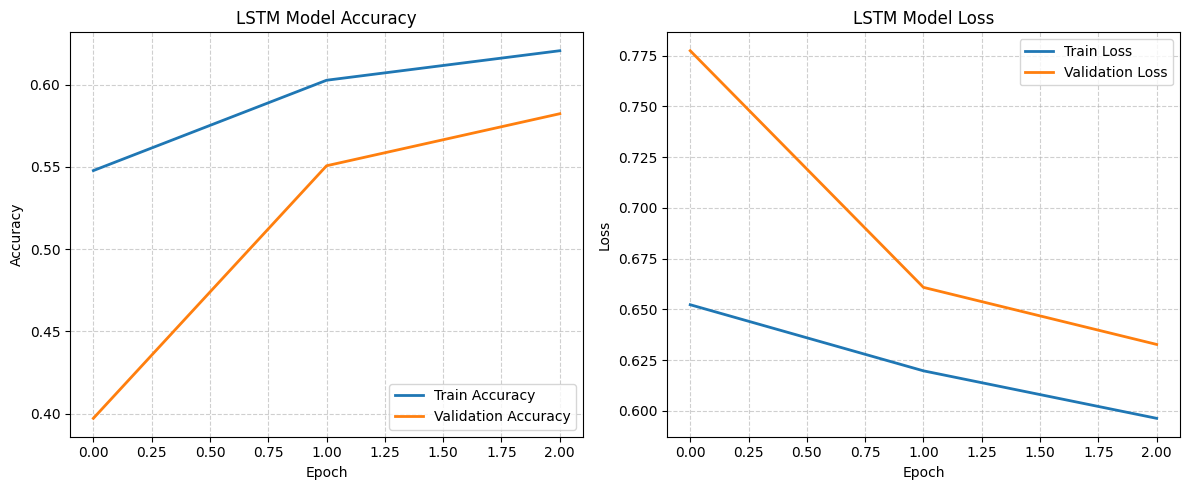

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy',     linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('LSTM Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss',     linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('LSTM Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Model Evaluation
Final classification report and confusion matrix using a threshold of 0.5. Recall is the primary metric for this industrial fault detection task.

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_val_final) > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_val_final, y_pred, target_names=['Healthy', 'Failure']))

print("Confusion Matrix:")
print(confusion_matrix(y_val_final, y_pred))

print(model.summary())

4604/4604 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.39      0.56    143580
     Failure       0.03      0.71      0.06      3727

    accuracy                           0.40    147307
   macro avg       0.51      0.55      0.31    147307
weighted avg       0.96      0.40      0.54    147307

Confusion Matrix:
[[55841 87739]
 [ 1064  2663]]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245 (86.90 KB)

 Trainable params: 7,393 (28.88 KB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 14,788 (57.77 KB)

None


## 10. Explainable AI — SHAP Analysis
SHAP GradientExplainer maps the LSTM's predictions back to individual sensor contributions.
- **Global Bar Chart**: Average feature importance across all 50 test samples
- **Waterfall Plot**: Single-prediction local explanation showing how each sensor pushed the model toward or away from predicting failure
- **Summary Beeswarm Plot**: Distribution of SHAP values across all test samples per feature

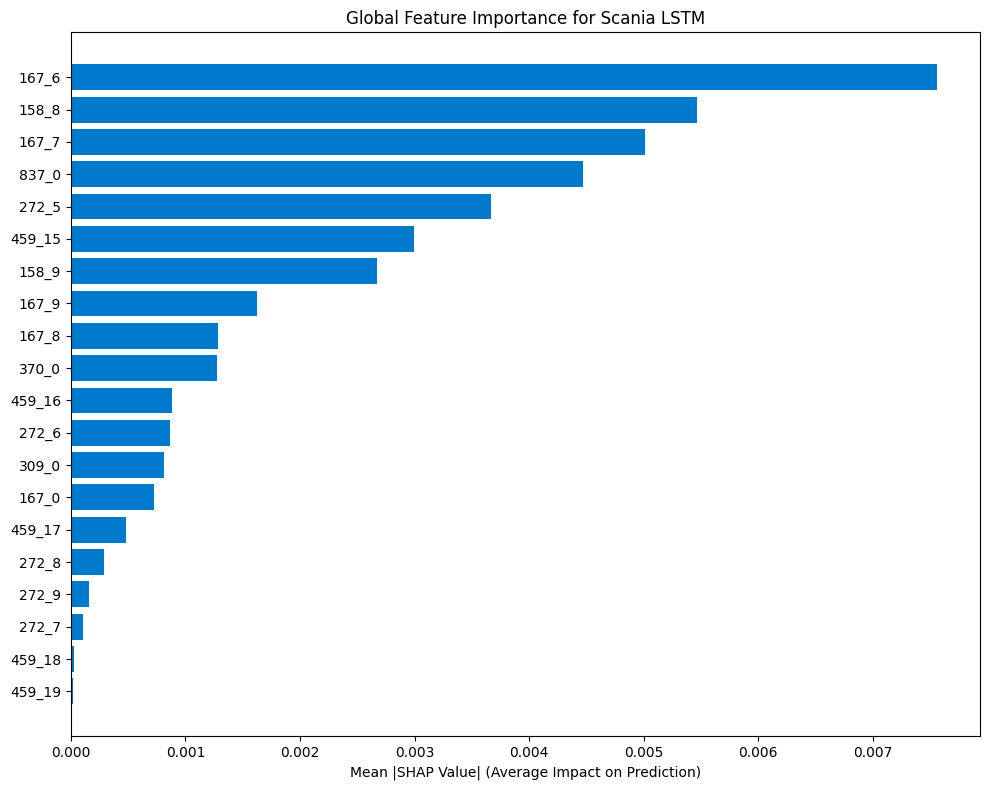

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


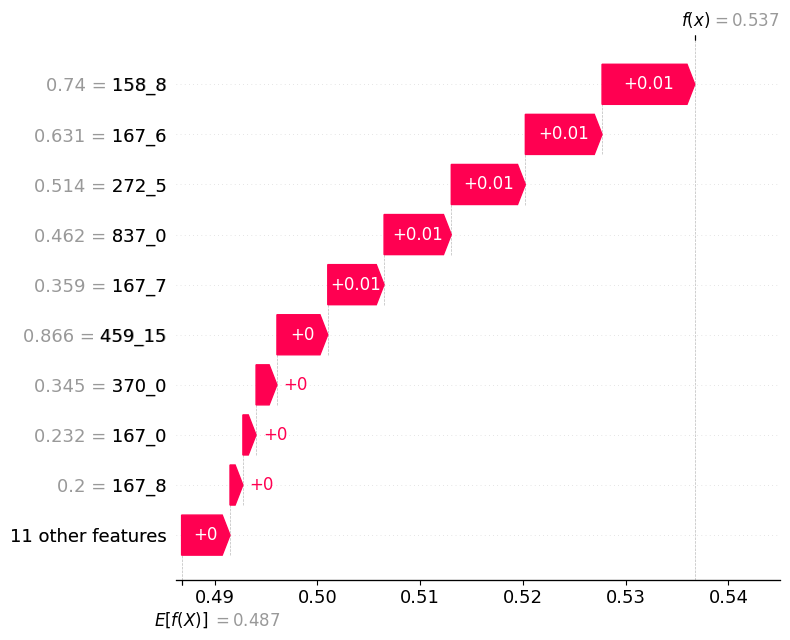

/tmp/ipython-input-239/3274819243.py:55: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_2d, X_val_2d,


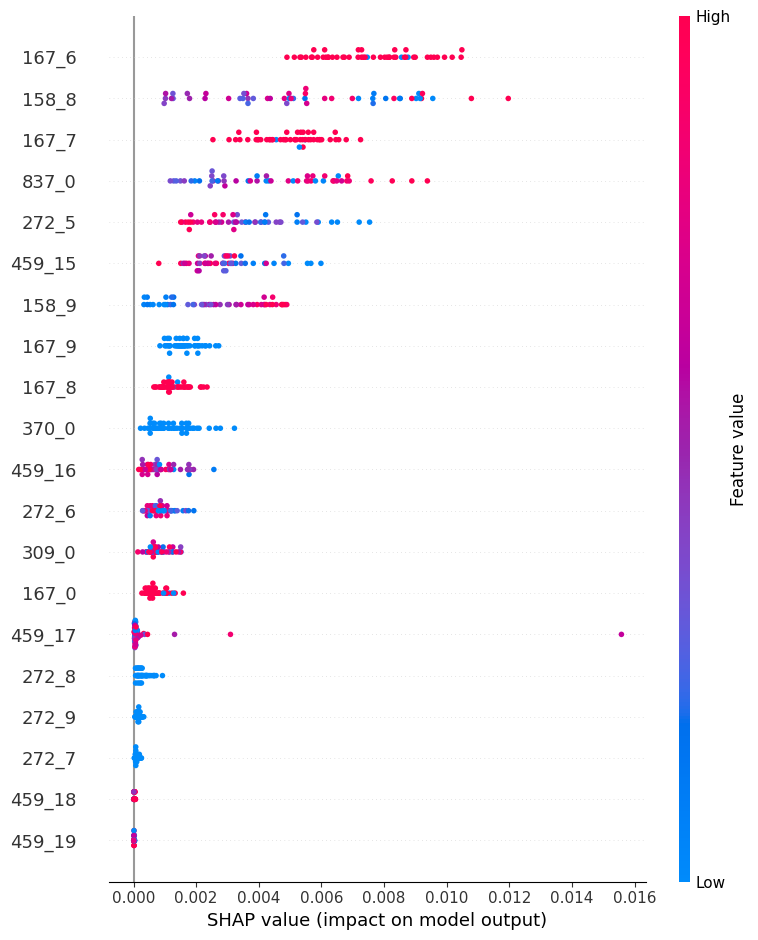

In [14]:
import shap
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

tf.experimental.numpy.experimental_enable_numpy_behavior()

# Sample background and test sequences
background_indices = np.random.choice(X_train_final.shape[0], 100, replace=False)
background         = tf.cast(X_train_final[background_indices], tf.float32)

explainer      = shap.GradientExplainer(model, background)
test_sequences = tf.cast(X_val_final[:50], tf.float32)

shap_values = explainer.shap_values(test_sequences)

if isinstance(shap_values, list):
    shap_values = shap_values[0]
if len(shap_values.shape) == 4:
    shap_values = shap_values[:, :, :, 0]

# Collapse timestep dimension → (50, 20)
shap_values_2d = np.abs(shap_values).mean(axis=1)
global_shap    = np.mean(shap_values_2d, axis=0)

sorted_idx      = np.argsort(global_shap)
sorted_features = [top_20_features[i] for i in sorted_idx]
sorted_values   = global_shap[sorted_idx]

# ── Plot 1: Global Feature Importance Bar Chart ──────────────────
plt.figure(figsize=(10, 8))
plt.barh(sorted_features, sorted_values, color='#007acc')
plt.xlabel('Mean |SHAP Value| (Average Impact on Prediction)')
plt.title('Global Feature Importance for Scania LSTM')
plt.tight_layout()
plt.savefig('shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Waterfall Plot (single prediction) ───────────────────
explanation = shap.Explanation(
    values=shap_values_2d[0],
    base_values=float(np.mean(model.predict(background.numpy()))),
    data=np.abs(X_val_final[:50]).mean(axis=1)[0],
    feature_names=top_20_features
)

plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Summary Beeswarm Plot (global distribution) ──────────
X_val_2d = X_val_final[:50].mean(axis=1)
shap.summary_plot(shap_values_2d, X_val_2d,
                  feature_names=top_20_features, show=False)
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()